# GREAD on GraphUniverse — supplementary transfer analysis

Model: GREAD (Choi et al., ICML 2023, [arXiv:2211.14208](https://arxiv.org/abs/2211.14208)), config `graph/gread`.

This notebook is **supplementary** to the official `run_evaluation.ipynb`. It
re-trains nothing: it reads the committed `results.json` from the official grid
and analyses the part of it that the official artifacts summarise only
partially — the **out-of-distribution (OOD) evaluations**.

The official run trains on each of the 12 GraphUniverse settings and evaluates
every checkpoint on all 12, so each model yields a full 12x12 transfer matrix
per task, per seed: 432 measurements per task, of which only the 36 diagonal
ones appear in the main heatmaps.

We use them to ask three questions the challenge itself poses:

1. Is performance governed by the distribution a model is **evaluated** on, or
   by the **mismatch** between training and evaluation distributions?
2. Is transfer across homophily levels **symmetric**?
3. Which structural axis — homophily, average degree, or power-law exponent —
   dominates?

The headline result is that the two tasks answer question 1 in **opposite**
ways.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

STUDY_ID = "2026-07-25_13-46-02"
RESULTS = Path("outputs") / STUDY_ID / "results.json"
if not RESULTS.exists():  # allow running from the repository root
    RESULTS = Path("2026_tdl_challenge") / RESULTS

# metric key, display label, better direction, whether to analyse on a log scale
TASK_METRIC = {
    "community_detection": ("test_best_rerun_accuracy", "accuracy", "max", False),
    "triangle_counting": ("test_mse_by_total_triangles", "MSE / triangles", "min", True),
}

REGIME_ORDER = [
    f"h_{h}__d_{d}__pl_{p}"
    for h in ("lo", "mid", "hi")
    for d in ("lo", "hi")
    for p in ("lo", "hi")
]
HOM_ORDER = ["lo", "mid", "hi"]


def load_long(path):
    """Flatten results.json into one row per (task, train regime, eval regime, seed)."""
    payload = json.loads(Path(path).read_text())
    rows = []
    for run in payload["results"]:
        task = run["experiment"]
        metric = TASK_METRIC[task][0]
        train = run["run_slug"]
        rows.append(
            dict(task=task, train=train, eval=train, seed=run["train_seed"],
                 in_distribution=True, score=run[metric])
        )
        for eval_slug, metrics in (run.get("ood_test") or {}).items():
            rows.append(
                dict(task=task, train=train, eval=eval_slug, seed=run["train_seed"],
                     in_distribution=False, score=metrics[metric])
            )
    frame = pd.DataFrame(rows)
    for col in ("train", "eval"):
        parts = frame[col].str.split("__", expand=True)
        frame[f"{col}_homophily"] = parts[0].str.removeprefix("h_")
        frame[f"{col}_degree"] = parts[1].str.removeprefix("d_")
        frame[f"{col}_powerlaw"] = parts[2].str.removeprefix("pl_")
    # Analysis scale: triangle-counting errors span several orders of magnitude,
    # so a raw-scale summary would be dominated by a handful of extreme cells.
    frame["value"] = frame.score
    log_tasks = [t for t, spec in TASK_METRIC.items() if spec[3]]
    mask = frame.task.isin(log_tasks)
    frame.loc[mask, "value"] = np.log10(frame.loc[mask, "score"].clip(lower=1e-6))
    return frame


df = load_long(RESULTS)
print(f"{len(df)} measurements "
      f"({df.in_distribution.sum()} in-distribution, {(~df.in_distribution).sum()} OOD)")
print("\ntriangle-counting MSE/triangles spans "
      f"{df[df.task == 'triangle_counting'].score.min():.4g} to "
      f"{df[df.task == 'triangle_counting'].score.max():.4g} "
      "-> analysed as log10")
df.head()

864 measurements (72 in-distribution, 792 OOD)

triangle-counting MSE/triangles spans 0.0139 to 2215 -> analysed as log10


,task,train,eval,seed,in_distribution,score,train_homophily,train_degree,train_powerlaw,eval_homophily,eval_degree,eval_powerlaw,value
0,community_detection,h_lo__d_lo__pl_lo,h_lo__d_lo__pl_lo,42,True,0.314692,lo,lo,lo,lo,lo,lo,0.314692
1,community_detection,h_lo__d_lo__pl_lo,h_lo__d_lo__pl_hi,42,False,0.312667,lo,lo,lo,lo,lo,hi,0.312667
2,community_detection,h_lo__d_lo__pl_lo,h_lo__d_hi__pl_lo,42,False,0.328711,lo,lo,lo,lo,hi,lo,0.328711
3,community_detection,h_lo__d_lo__pl_lo,h_lo__d_hi__pl_hi,42,False,0.326610,lo,lo,lo,lo,hi,hi,0.326610
4,community_detection,h_lo__d_lo__pl_lo,h_mid__d_lo__pl_lo,42,False,0.348079,lo,lo,lo,mid,lo,lo,0.348079


## 1. Evaluation distribution, or train/eval mismatch?

An OOD drop is usually read as a transfer failure. But the same drop appears if
the target distribution is simply harder, wherever the model was trained. The
two explanations make different predictions:

- *Mismatch matters*: scores depend on the **training** regime.
- *Target difficulty matters*: scores depend on the **evaluation** regime.

We quantify this as the fraction of score variance explained by grouping the
432 measurements by evaluation regime, versus by training regime.

In [2]:
def variance_explained(frame, by, col="value"):
    """Fraction of variance in `col` explained by grouping on `by`."""
    group_mean = frame.groupby(by)[col].transform("mean")
    resid = ((frame[col] - group_mean) ** 2).mean()
    total = ((frame[col] - frame[col].mean()) ** 2).mean()
    return 1.0 - resid / total


summary = []
for task, sub in df.groupby("task"):
    metric, label, _, is_log = TASK_METRIC[task]
    summary.append(
        dict(
            task=task,
            analysed=f"log10({label})" if is_log else label,
            by_eval_regime=variance_explained(sub, "eval"),
            by_train_regime=variance_explained(sub, "train"),
        )
    )
variance_table = pd.DataFrame(summary).set_index("task").round(3)
variance_table

,analysed,by_eval_regime,by_train_regime
task,,,
community_detection,accuracy,0.767,0.038
triangle_counting,log10(MSE / triangles),0.105,0.427


The two tasks behave in opposite ways, and this is the main result of the
notebook.

**Community detection** is governed by the evaluation regime: it explains an
order of magnitude more variance than the training regime. The model transfers
well; the regimes differ in intrinsic difficulty. Reporting an "OOD gap" here
without this decomposition would attribute to distribution shift what is mostly
a difficulty effect.

**Triangle counting** is the reverse: the training regime dominates. This is a
genuine distribution-shift failure. A count is an extensive quantity whose
typical magnitude changes by orders of magnitude across regimes, so a regressor
calibrated on one regime systematically mispredicts the scale elsewhere — a
calibration failure rather than a failure to perceive structure.

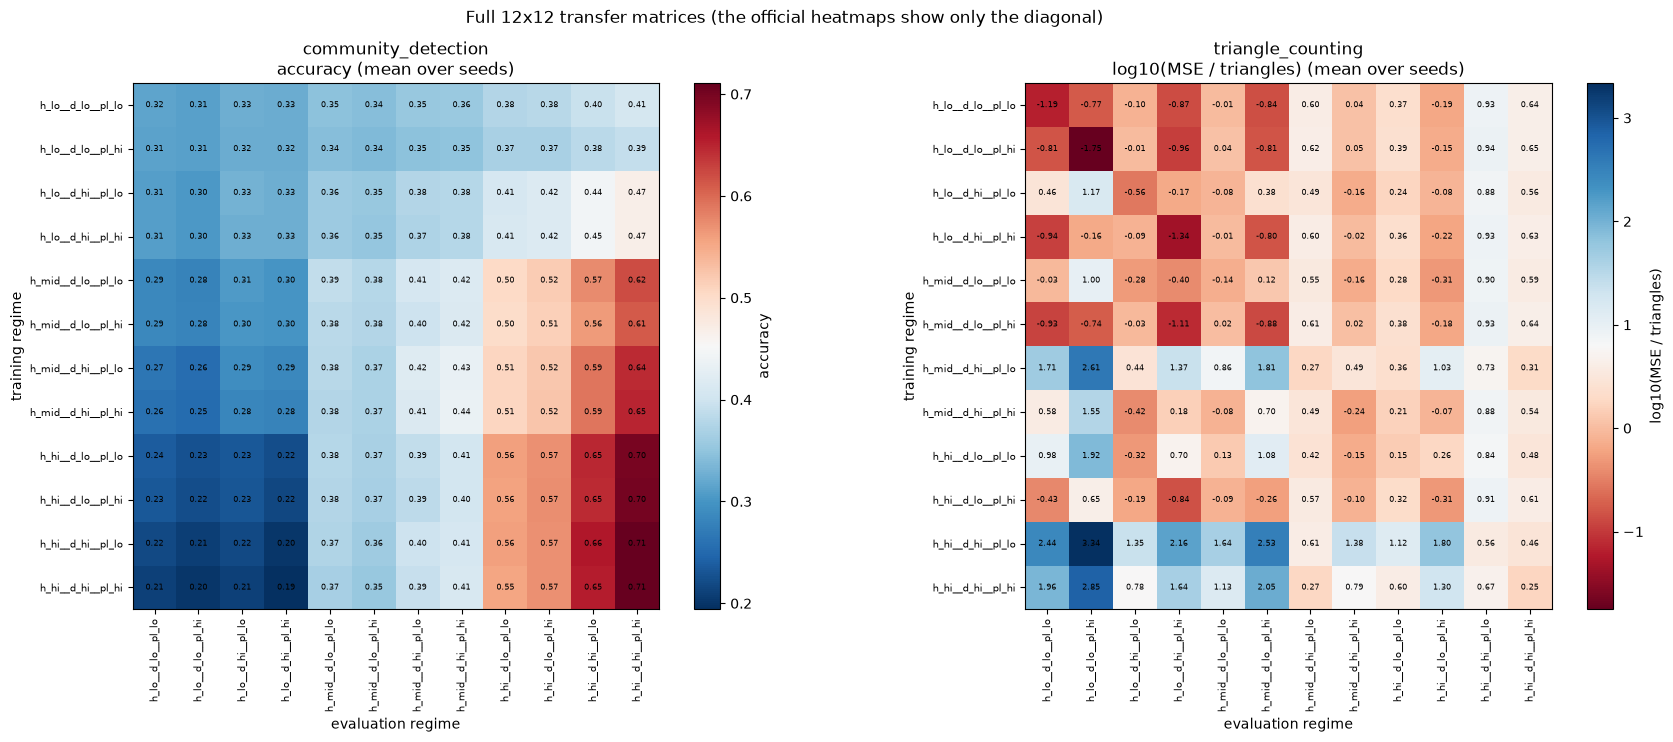

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))
for ax, (task, (metric, label, direction, is_log)) in zip(axes, TASK_METRIC.items()):
    sub = df[df.task == task]
    matrix = (
        sub.pivot_table(index="train", columns="eval", values="value", aggfunc="mean")
        .reindex(index=REGIME_ORDER, columns=REGIME_ORDER)
    )
    data = matrix.to_numpy()
    im = ax.imshow(data, cmap="RdBu_r" if direction == "max" else "RdBu")
    ax.set_xticks(range(len(REGIME_ORDER)))
    ax.set_yticks(range(len(REGIME_ORDER)))
    ax.set_xticklabels(REGIME_ORDER, rotation=90, fontsize=7)
    ax.set_yticklabels(REGIME_ORDER, fontsize=7)
    ax.set_xlabel("evaluation regime")
    ax.set_ylabel("training regime")
    shown = f"log10({label})" if is_log else label
    ax.set_title(f"{task}\n{shown} (mean over seeds)")
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f"{data[i, j]:.2f}", ha="center", va="center", fontsize=6)
    fig.colorbar(im, ax=ax, fraction=0.046, label=shown)
fig.suptitle("Full 12x12 transfer matrices (the official heatmaps show only the diagonal)")
fig.tight_layout()
plt.show()

Read the two panels by comparing how each varies. Community detection varies
mostly left-to-right (along the evaluation axis); triangle counting varies
mostly top-to-bottom (along the training axis).

## 2. Is transfer across homophily symmetric?

Collapsing onto the homophily axis isolates the structural property the
challenge cares most about. Symmetric transfer would give a symmetric matrix.

In [4]:
for task, (metric, label, direction, is_log) in TASK_METRIC.items():
    sub = df[df.task == task]
    shown = f"log10({label})" if is_log else label
    hom = (
        sub.pivot_table(index="train_homophily", columns="eval_homophily",
                        values="value", aggfunc="mean")
        .reindex(index=HOM_ORDER, columns=HOM_ORDER)
    )
    print(f"\n{task} — {shown} (rows = trained on, cols = evaluated on)")
    print(hom.round(3).to_string())
    print(f"  trained hi -> evaluated lo : {hom.loc['hi', 'lo']:.3f} "
          f"(native lo = {hom.loc['lo', 'lo']:.3f})")
    print(f"  trained lo -> evaluated hi : {hom.loc['lo', 'hi']:.3f} "
          f"(native hi = {hom.loc['hi', 'hi']:.3f})")
    best = hom.mean(axis=1)
    best = best.idxmax() if direction == "max" else best.idxmin()
    print(f"  best generalist (row mean over all eval regimes): trained on h_{best}")


community_detection — accuracy (rows = trained on, cols = evaluated on)
eval_homophily      lo    mid     hi
train_homophily                     
lo               0.318  0.357  0.410
mid              0.283  0.398  0.559
hi               0.219  0.384  0.621
  trained hi -> evaluated lo : 0.219 (native lo = 0.318)
  trained lo -> evaluated hi : 0.410 (native hi = 0.621)
  best generalist (row mean over all eval regimes): trained on h_mid

triangle_counting — log10(MSE / triangles) (rows = trained on, cols = evaluated on)
eval_homophily      lo    mid     hi
train_homophily                     
lo              -0.506  0.006  0.430
mid              0.344  0.276  0.452
hi               1.186  0.751  0.627
  trained hi -> evaluated lo : 1.186 (native lo = -0.506)
  trained lo -> evaluated hi : 0.430 (native hi = 0.627)
  best generalist (row mean over all eval regimes): trained on h_lo


Transfer is clearly asymmetric, and the asymmetry runs in opposite directions
for the two tasks. For community detection the mid-homophily model is the best
generalist, and a high-homophily model degrades badly on heterophilic graphs.
For triangle counting the low-homophily model is the safest, because it is
calibrated to the sparse-triangle end of the scale.

## 3. Which structural axis dominates?

Variance explained by each axis of the *evaluation* regime alone.

In [5]:
axis_rows = []
for task, sub in df.groupby("task"):
    for prefix in ("eval", "train"):
        for axis in ("homophily", "degree", "powerlaw"):
            axis_rows.append(
                dict(task=task, side=prefix, axis=axis,
                     variance_explained=variance_explained(sub, f"{prefix}_{axis}"))
            )
axis_table = (
    pd.DataFrame(axis_rows)
    .pivot(index=["task", "side"], columns="axis", values="variance_explained")
    .round(3)
)
print(axis_table.to_string())

print("\nMean value by regime level (log10 scale for triangle counting):")
for task, (metric, label, direction, is_log) in TASK_METRIC.items():
    sub = df[df.task == task]
    side = "eval" if task == "community_detection" else "train"
    for axis in ("homophily", "degree", "powerlaw"):
        means = sub.groupby(f"{side}_{axis}").value.mean().round(3).to_dict()
        print(f"  {task:20s} {side}_{axis:10s} {means}")

axis                       degree  homophily  powerlaw
task                side                              
community_detection eval    0.026      0.722     0.001
                    train   0.001      0.035     0.000
triangle_counting   eval    0.003      0.008     0.000
                    train   0.147      0.178     0.046

Mean value by regime level (log10 scale for triangle counting):
  community_detection  eval_homophily  {'hi': 0.53, 'lo': 0.273, 'mid': 0.38}
  community_detection  eval_degree     {'hi': 0.414, 'lo': 0.374}
  community_detection  eval_powerlaw   {'hi': 0.398, 'lo': 0.391}
  triangle_counting    train_homophily  {'hi': 0.855, 'lo': -0.024, 'mid': 0.357}
  triangle_counting    train_degree     {'hi': 0.723, 'lo': 0.069}
  triangle_counting    train_powerlaw   {'hi': 0.212, 'lo': 0.58}


Homophily dominates in both cases — on the evaluation side for community
detection and on the training side for triangle counting. Average degree and the
power-law exponent are secondary throughout.

## 4. Seed stability

Three seeds per (task, regime). Small dispersion is what licenses reading the
differences above as real rather than as noise.

In [6]:
stability = []
for task, sub in df[df.in_distribution].groupby("task"):
    per_regime = sub.groupby("train").score
    stability.append(
        dict(task=task, metric=TASK_METRIC[task][1],
             max_seed_std=per_regime.std().max(),
             median_seed_std=per_regime.std().median(),
             spread_across_regimes=per_regime.mean().max() - per_regime.mean().min())
    )
pd.DataFrame(stability).set_index("task").round(4)

,metric,max_seed_std,median_seed_std,spread_across_regimes
task,,,,
community_detection,accuracy,0.0035,0.0014,0.3978
triangle_counting,MSE / triangles,0.0549,0.0065,3.6515


## Takeaways

1. **The two tasks fail differently.** For community detection, GREAD's score is
   set by the regime it is *evaluated* on (variance explained 0.77)
   and barely by the one it was *trained* on (0.04). The apparent
   OOD penalty is target difficulty, not failed transfer. For triangle counting
   the ordering reverses on a log scale (train 0.43 vs eval
   0.11): that task does exhibit a real distribution-shift failure.
2. **Counting fails by miscalibrated scale.** Triangle counts are extensive and
   their magnitude shifts by orders of magnitude across regimes, so a model
   calibrated on one regime mispredicts the scale on another. The worst cells of
   the transfer matrix are exactly the largest scale jumps.
3. **Homophily transfer is asymmetric**, in opposite directions per task: the
   best community-detection generalist here is the model trained on
   mid homophily, whereas the safest triangle counter is the
   one trained on low homophily, which is calibrated to the sparse-triangle end
   of the scale.
4. **Methodological note.** Any OOD summary of a regression task on this grid
   should be read on a log scale; on the raw scale a few extreme cells dominate
   the statistics and invert the conclusion.

All numbers derive from the committed `results.json`. Nothing here re-trains or
modifies the official evaluation pipeline.